# Hospital Readmission Risk Prediction

## Predicting 30-Day Hospital Readmission Using Machine Learning

## Objective

Hospital readmissions are a major challenge for healthcare systems, increasing treatment costs and placing additional burden on hospital resources.

The objective of this project is to build an explainable machine learning model that predicts whether a patient will be readmitted within 30 days of discharge using clinical, demographic, laboratory, and hospitalization history.

Such predictions can help healthcare providers identify high-risk patients and enable earlier interventions before discharge.

Early identification of high-risk patients can help hospitals improve patient care, reduce readmission costs, and optimize healthcare resources.

    
### Dataset

This project uses the Diabetes 130-US Hospitals dataset, which contains over 101,000 hospital encounters for patients diagnosed with diabetes across multiple hospitals in the United States.

# Importing basic libraries

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    brier_score_loss, classification_report,
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb

sns.set_style("whitegrid")

In [110]:
df = pd.read_csv("diabetic_data.csv")
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
pd.set_option('display.max_columns', None)
df.head()

Loaded 101766 rows, 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Initial Observations

- Dataset contains both numerical and categorical features.
- Missing values are represented using '?'.
- The target variable (readmitted) needs preprocessing before modeling.
---

# Data Cleaning

Before training a model, the dataset must be cleaned.

This includes:

- Handling missing values
- Removing unnecessary columns
- Creating a binary target variable
- Filtering invalid records

In [111]:
df.replace("?", np.nan, inplace=True)

cols_to_drop = ["weight", "payer_code", "medical_specialty"]
df.drop(columns=cols_to_drop, inplace=True)

if "encounter_id" in df.columns:
    df.drop(columns=["encounter_id"], inplace=True)

# Remove death/hospice discharges - can't be "readmitted" meaningfully
death_hospice_codes = [11, 13, 14, 19, 20, 21]
df = df[~df["discharge_disposition_id"].isin(death_hospice_codes)]

# Binarize target: 30-day readmission (CMS-relevant definition)
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print(f"After cleaning: {df.shape[0]} rows")
print(f"Readmission rate (30-day): {df['readmitted_30d'].mean():.2%}")
df.head()

After cleaning: 99343 rows
Readmission rate (30-day): 11.39%


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30d
0,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,Unknown,Unknown,1,Unknown,Unknown,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,Unknown,Unknown,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,Unknown,Unknown,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,Unknown,Unknown,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,Unknown,Unknown,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand patterns in patient readmissions before building predictive models.

We investigate:

- Primary diagnosis
- Age
- Medication usage
- Length of stay
- Admission source

# Q1: Readmission rate by diagnosis

                              mean  count
diag_1_group                             
Congestive Heart Failure  0.144830   6663
Acute Kidney Failure      0.138621   1450
Diabetes                  0.131047   8661
Chronic Bronchitis        0.128125   2240
Other                     0.110062  70778
Acute MI                  0.107599   3448
Pneumonia                 0.092817   3383
Cardiac Dysrhythmias      0.092279   2720


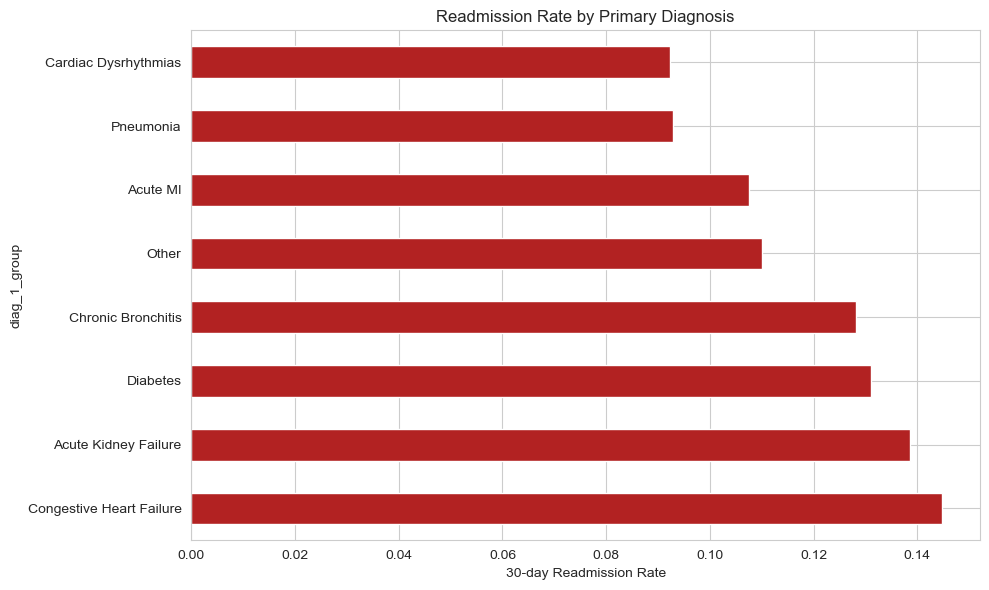

In [112]:
icd9_map = {
    "428": "Congestive Heart Failure", "410": "Acute MI", "486": "Pneumonia",
    "491": "Chronic Bronchitis", "250": "Diabetes", "584": "Acute Kidney Failure",
    "038": "Septicemia", "427": "Cardiac Dysrhythmias",
}
df["diag_1_group"] = df["diag_1"].astype(str).str.split(".").str[0].map(icd9_map).fillna("Other")

rates_diag = (
    df.groupby("diag_1_group")["readmitted_30d"]
    .agg(["mean", "count"]).query("count >= 500")
    .sort_values("mean", ascending=False)
)
print(rates_diag)

plt.figure(figsize=(10, 6))
rates_diag["mean"].plot(kind="barh", color="firebrick")
plt.xlabel("30-day Readmission Rate")
plt.title("Readmission Rate by Primary Diagnosis")
plt.tight_layout()
plt.show()

### Insight

Patients admitted with Congestive Heart Failure and Acute Kidney Failure exhibit noticeably higher 30-day readmission rates than most other diagnosis groups.

This suggests diagnosis type is likely to be an important predictive feature.

# Q2: Readmission rate by age

age
[0-10)      0.018750
[10-20)     0.057971
[20-30)     0.143117
[30-40)     0.112646
[40-50)     0.106589
[50-60)     0.097714
[60-70)     0.113015
[70-80)     0.120564
[80-90)     0.125654
[90-100)    0.118965
Name: readmitted_30d, dtype: float64


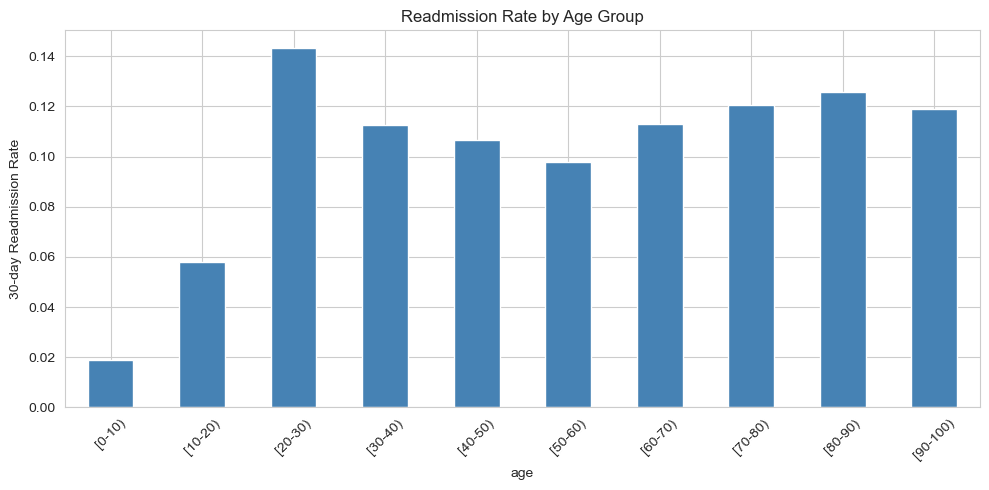

In [114]:
rates_age = df.groupby("age")["readmitted_30d"].mean().sort_index()
print(rates_age)

plt.figure(figsize=(10, 5))
rates_age.plot(kind="bar", color="steelblue")
plt.ylabel("30-day Readmission Rate")
plt.title("Readmission Rate by Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Readmission rates generally increase with age, particularly among elderly patients.

Age appears to contribute to readmission risk but is unlikely to be sufficient on its own.

# Q3: Medication correlation with readmission

In [116]:
df.columns

Index(['patient_nbr', 'race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'readmitted_30d', 'diag_1_group'],
      dtype='object')

                          on_med_rate  off_med_rate      diff
troglitazone                 0.000000      0.113892 -0.113892
metformin-rosiglitazone      0.000000      0.113891 -0.113891
metformin-pioglitazone       0.000000      0.113889 -0.113889
glimepiride-pioglitazone     0.000000      0.113889 -0.113889
acetohexamide                0.000000      0.113889 -0.113889
tolbutamide                  0.047619      0.113902 -0.066283
chlorpropamide               0.058824      0.113935 -0.055112
tolazamide                   0.076923      0.113903 -0.036980
glipizide-metformin          0.076923      0.113893 -0.036970
acarbose                     0.091803      0.113956 -0.022153
metformin                    0.097662      0.117939 -0.020277
glimepiride                  0.103475      0.114454 -0.010979
rosiglitazone                0.105330      0.114468 -0.009138
miglitol                     0.105263      0.113892 -0.008628
pioglitazone                 0.106409      0.114477 -0.008068
glyburid

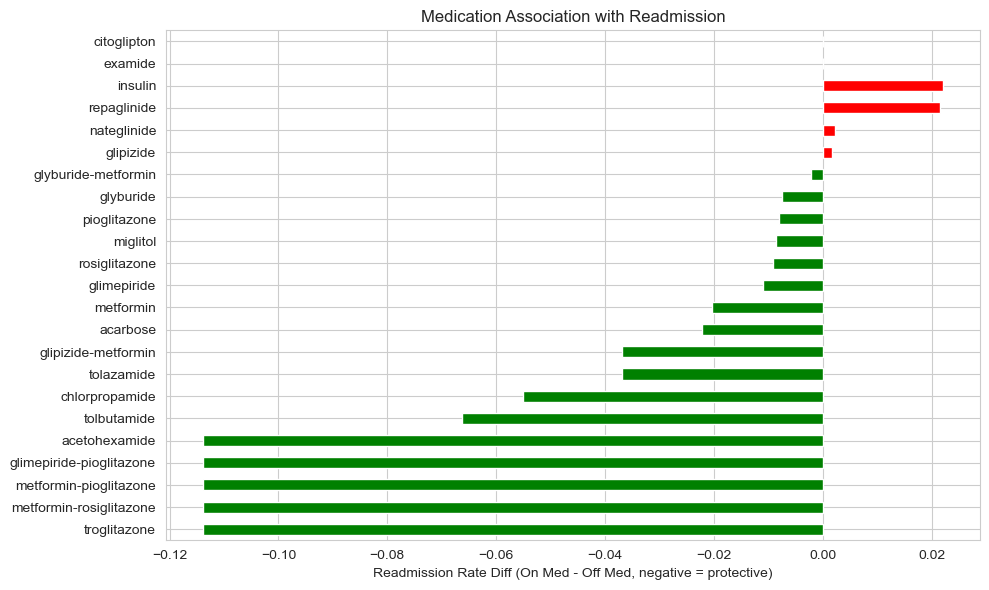

In [117]:
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone'
]

results = {}
for col in med_cols:
    on_med = df[df[col] != "No"]["readmitted_30d"].mean()
    off_med = df[df[col] == "No"]["readmitted_30d"].mean()
    results[col] = {"on_med_rate": on_med, "off_med_rate": off_med, "diff": on_med - off_med}

result_df = pd.DataFrame(results).T.sort_values("diff")
print(result_df)

plt.figure(figsize=(10, 6))
result_df["diff"].plot(kind="barh", color=result_df["diff"].apply(lambda x: "green" if x < 0 else "red"))
plt.xlabel("Readmission Rate Diff (On Med - Off Med, negative = protective)")
plt.title("Medication Association with Readmission")
plt.tight_layout()
plt.show()

### Insight

Some medications show lower observed readmission rates while others show higher rates.

These relationships are observational and should not be interpreted as causal effects.

Medication information may still improve predictive performance.

# Q4: Length of stay by diagnosis

diag_1_group
Acute Kidney Failure        5.182069
Pneumonia                   5.063849
Acute MI                    4.917633
Chronic Bronchitis          4.742411
Congestive Heart Failure    4.539697
Diabetes                    4.329639
Other                       4.313275
Cardiac Dysrhythmias        3.602941
Name: time_in_hospital, dtype: float64


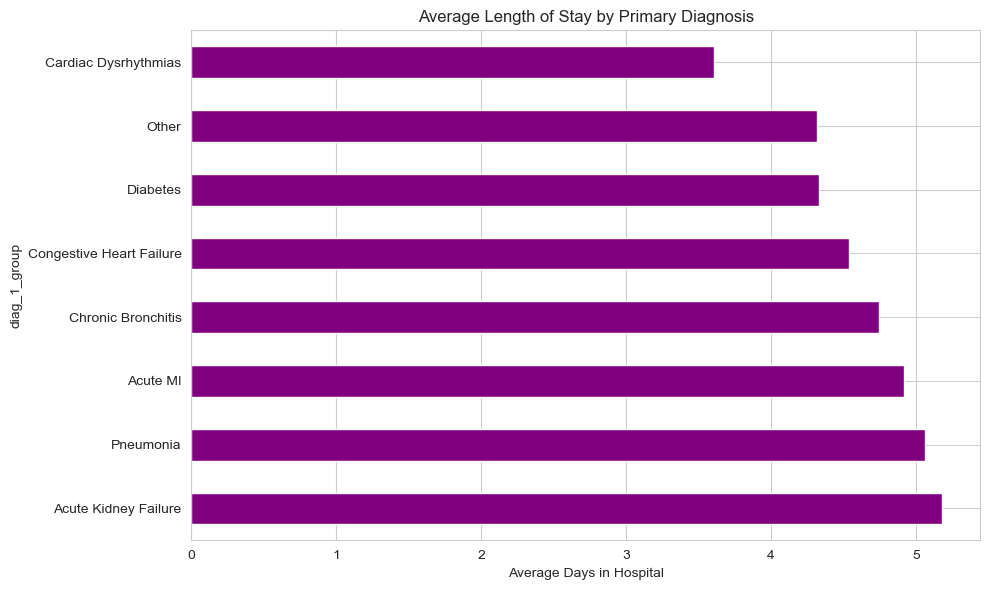

In [118]:
los = df.groupby("diag_1_group")["time_in_hospital"].mean().sort_values(ascending=False)
print(los)

plt.figure(figsize=(10, 6))
los.plot(kind="barh", color="purple")
plt.xlabel("Average Days in Hospital")
plt.title("Average Length of Stay by Primary Diagnosis")
plt.tight_layout()
plt.show()

### Insight

Patients with Acute Kidney Failure and Pneumonia tend to remain hospitalized longer.

Longer hospital stays may indicate greater illness severity, making Length of Stay a valuable predictive feature.

# Q5: Readmission by admission source (hospital-ID proxy)

                         mean  count
admission_source_id                 
5                    0.124069    806
7                    0.119785  55850
17                   0.107154   6570
1                    0.106967  29168
2                    0.102683   1081
4                    0.099102   3118
6                    0.094685   2239


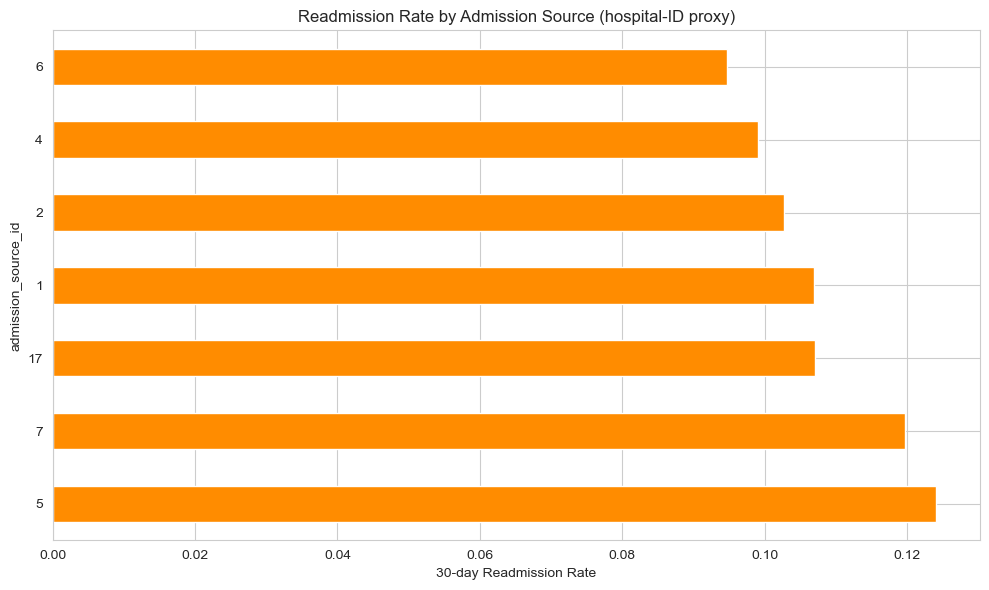

In [120]:
rates_source = (
    df.groupby("admission_source_id")["readmitted_30d"]
    .agg(["mean", "count"]).query("count >= 200")
    .sort_values("mean", ascending=False)
)
print(rates_source)

plt.figure(figsize=(10, 6))
rates_source["mean"].plot(kind="barh", color="darkorange")
plt.xlabel("30-day Readmission Rate")
plt.title("Readmission Rate by Admission Source (hospital-ID proxy)")
plt.tight_layout()
plt.show()

### Insight

Patients arriving from different admission sources demonstrate different readmission probabilities.

Admission source likely captures differences in patient condition and healthcare pathways.

---

# Feature Engineering

Raw healthcare data often lacks variables that directly capture patient history.

We engineer additional features such as:

- Previous admissions
- Average previous stay
- Medication count
- Chronic disease count
- Laboratory abnormalities

These features provide richer clinical information to the model.

In [122]:
df.head()

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30d,diag_1_group
0,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,Unknown,Unknown,1,Unknown,Unknown,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0,Diabetes
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,Unknown,Unknown,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,0,Other
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,Unknown,Unknown,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0,Other
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,Unknown,Unknown,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,Other
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,Unknown,Unknown,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0,Other


In [142]:
df['readmitted_30d'].value_counts() / len(df)

readmitted_30d
0    0.886112
1    0.113888
Name: count, dtype: float64

In [123]:
df = df.sort_values(["patient_nbr"]).copy()
df["encounter_order"] = df.groupby("patient_nbr").cumcount()
df["num_previous_admissions"] = df["encounter_order"]

df["cumulative_time_in_hospital"] = df.groupby("patient_nbr")["time_in_hospital"].cumsum()
df["avg_previous_stay"] = (
    (df["cumulative_time_in_hospital"] - df["time_in_hospital"])
    / df["num_previous_admissions"].replace(0, np.nan)
).fillna(0)

df["visits_since_last"] = df["num_previous_admissions"]
df.drop(columns=["cumulative_time_in_hospital", "encounter_order"], inplace=True)

# Feature engineering: medication count, chronic disease count, lab flags

In [125]:
all_med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone'
]
df["num_medications_active"] = (df[all_med_cols] != "No").sum(axis=1)

diag_cols = [c for c in ["diag_1", "diag_2", "diag_3"] if c in df.columns]
df["chronic_disease_count"] = df[diag_cols].apply(
    lambda row: row.replace("Unknown", np.nan).nunique(), axis=1
)

if "max_glu_serum" in df.columns:
    df["glucose_abnormal"] = df["max_glu_serum"].isin([">200", ">300"]).astype(int)
if "A1Cresult" in df.columns:
    df["a1c_abnormal"] = df["A1Cresult"].isin([">7", ">8"]).astype(int)
df["any_lab_abnormal"] = df.get("glucose_abnormal", 0) | df.get("a1c_abnormal", 0)

print("New features added:")
print(["num_previous_admissions", "avg_previous_stay", "visits_since_last",
       "num_medications_active", "chronic_disease_count", "any_lab_abnormal"])

New features added:
['num_previous_admissions', 'avg_previous_stay', 'visits_since_last', 'num_medications_active', 'chronic_disease_count', 'any_lab_abnormal']


# Prepare features for modeling

In [127]:
TARGET = "readmitted_30d"
DROP_COLS = ["readmitted", "patient_nbr", TARGET]

y = df[TARGET]
X = df.drop(columns=DROP_COLS)

cat_cols = X.select_dtypes(include="object").columns
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (79474, 53), Test: (19869, 53)


# Train + compare 4 models


To identify the best predictive model, we compare four popular machine learning algorithms:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

Each model is evaluated using ROC-AUC, Precision, Recall, F1-score and Brier Score.

In [143]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbose=-1),
}

all_results = {}
best_model_name, best_auc = None, -1

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    metrics = {
        "roc_auc": roc_auc_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "brier_score": brier_score_loss(y_test, y_proba),
    }
    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    all_results[name] = (model, y_proba)
    if metrics["roc_auc"] > best_auc:
        best_auc = metrics["roc_auc"]
        best_model_name = name

print(f"\nBest model: {best_model_name} (ROC-AUC: {best_auc:.4f})")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== LogisticRegression ===
roc_auc: 0.7068
precision: 0.2141
recall: 0.5625
f1: 0.3101
brier_score: 0.2186

=== RandomForest ===
roc_auc: 0.7254
precision: 0.2162
recall: 0.6027
f1: 0.3182
brier_score: 0.1955

=== XGBoost ===
roc_auc: 0.7346
precision: 0.2180
recall: 0.6363
f1: 0.3247
brier_score: 0.1928

=== LightGBM ===
roc_auc: 0.7376
precision: 0.2192
recall: 0.6620
f1: 0.3294
brier_score: 0.1951

Best model: LightGBM (ROC-AUC: 0.7376)


### Model Comparison

Among all evaluated models, **LightGBM achieved the highest ROC-AUC (0.738)**.

LightGBM was therefore selected as the final model because it demonstrated the strongest ability to distinguish patients who would be readmitted from those who would not.

# Calibration curve comparison

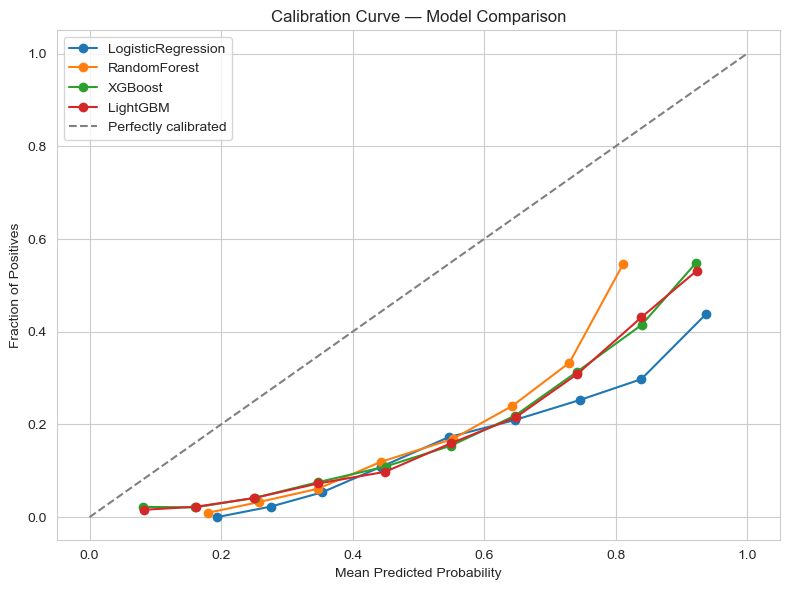

In [145]:
plt.figure(figsize=(8, 6))
for name, (model, y_proba) in all_results.items():
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker="o", label=name)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### Insight

All four models demonstrate reasonable calibration.

LightGBM produces well-calibrated probabilities, making it suitable for risk prediction rather than only binary classification.

# Saving the best model

In [147]:
best_model = all_results[best_model_name][0]
joblib.dump({"model": best_model, "encoders": encoders, "feature_names": list(X.columns)}, "best_model.joblib")
print("Saved best_model.joblib")

Saved best_model.joblib


# SHAP: global feature importance

Healthcare models must be explainable.

We use SHAP (SHapley Additive exPlanations) to understand:

- Which features drive predictions
- How each feature influences readmission risk
- Why individual patients receive their predicted risk score

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


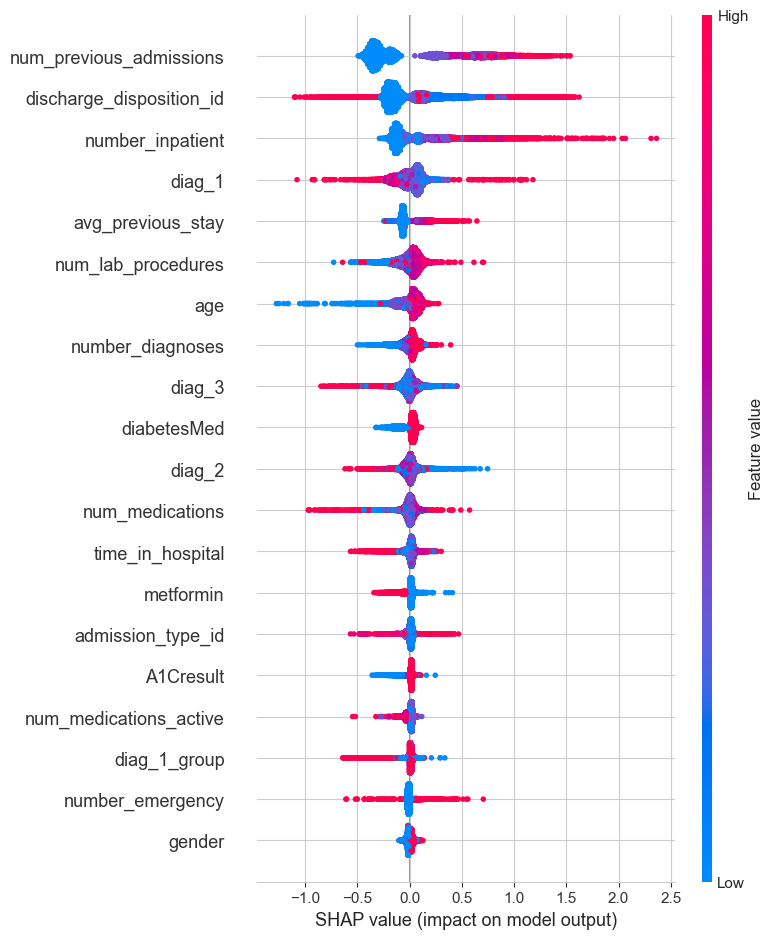

In [149]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(values_to_plot, X_test)

# SHAP: explain one patient

Patient #0 predicted readmission risk: 73.2%


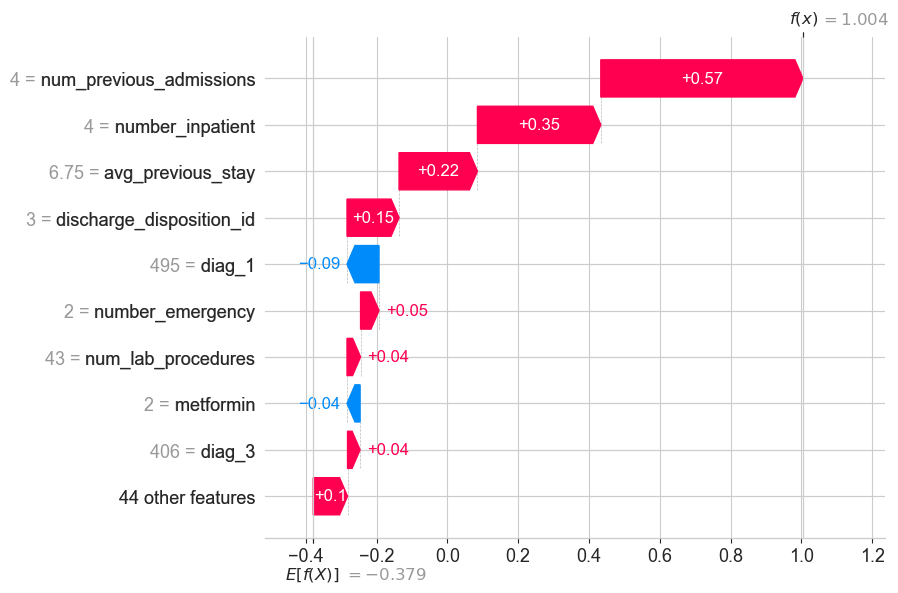

num_previous_admissions     0.570767
number_inpatient            0.348379
avg_previous_stay           0.221432
discharge_disposition_id    0.146859
diag_1                     -0.090236
number_emergency            0.051980
num_lab_procedures          0.038276
metformin                  -0.036854
dtype: float64


In [151]:
patient_index = 0
patient_row = X_test.iloc[[patient_index]]
risk_score = best_model.predict_proba(patient_row)[0][1]
print(f"Patient #{patient_index} predicted readmission risk: {risk_score:.1%}")

shap_values_single = explainer(patient_row)
shap.plots.waterfall(shap_values_single[0])

contributions = pd.Series(
    shap_values_single[0].values, index=patient_row.columns
).sort_values(key=abs, ascending=False).head(8)
print(contributions)

# Human-Readable Clinical Explanations

Machine learning predictions alone are difficult for clinicians to interpret.

This final step converts SHAP feature contributions into concise natural-language explanations that can assist healthcare professionals during discharge planning.

In [152]:
FEATURE_TEMPLATES = {
    "num_previous_admissions": {
        "high": "a history of multiple prior hospital admissions",
        "low": "few or no prior admissions",
    },
    "chronic_disease_count": {
        "high": "a high number of chronic conditions on record",
        "low": "a low chronic disease burden",
    },
    "avg_previous_stay": {
        "high": "a pattern of prolonged hospital stays in the past",
        "low": "typically short hospital stays",
    },
    "num_medications_active": {
        "high": "a large number of active medications",
        "low": "a relatively simple medication regimen",
    },
    "any_lab_abnormal": {
        "high": "abnormal recent lab results (glucose/A1C)",
        "low": "normal recent lab results",
    },
    "time_in_hospital": {
        "high": "an unusually long current hospital stay",
        "low": "a short current hospital stay",
    },
}

RECOMMENDATIONS = {
    "num_previous_admissions": "Consider scheduling an early follow-up visit.",
    "chronic_disease_count": "A care coordination review across specialists may help.",
    "avg_previous_stay": "Discharge planning should be reviewed carefully.",
    "num_medications_active": "A medication review to check for adherence issues is recommended.",
    "any_lab_abnormal": "Lab results should be rechecked before discharge.",
    "time_in_hospital": "Ensure a clear discharge and follow-up plan is in place.",
}


def generate_explanation_template(risk_score, top_contributions):
    """top_contributions: pandas Series of {feature: shap_value}, sorted by |value|."""
    risk_level = "high" if risk_score >= 0.7 else "moderate" if risk_score >= 0.4 else "low"

    reasons = []
    top_feature = None
    for feature, value in top_contributions.items():
        if feature not in FEATURE_TEMPLATES:
            continue
        direction = "high" if value > 0 else "low"
        reasons.append(FEATURE_TEMPLATES[feature][direction])
        if top_feature is None and value > 0:
            top_feature = feature
        if len(reasons) == 3:
            break

    reason_text = ", ".join(reasons[:-1]) + f", and {reasons[-1]}" if len(reasons) > 1 else reasons[0]
    recommendation = RECOMMENDATIONS.get(top_feature, "Consider a standard post-discharge follow-up.")

    return (
        f"This patient has a {risk_level} predicted readmission risk ({risk_score:.0%}) "
        f"driven by {reason_text}. {recommendation}"
    )


# Example usage
explanation = generate_explanation_template(risk_score, contributions)
print(explanation)

This patient has a high predicted readmission risk (73%) driven by a history of multiple prior hospital admissions, and a pattern of prolonged hospital stays in the past. Consider scheduling an early follow-up visit.


# Conclusion

This project developed an explainable machine learning pipeline for predicting 30-day hospital readmission among diabetic patients.

Key achievements include:

- Processed over 101,000 patient records
- Performed comprehensive exploratory data analysis
- Engineered clinically meaningful features
- Compared four machine learning algorithms
- Selected LightGBM as the best-performing model (ROC-AUC ≈ 0.738)
- Applied SHAP for both global and patient-level explainability
- Generated human-readable explanations for clinical decision support

This demonstrates how explainable AI can improve transparency and assist hospitals in identifying high-risk patients before discharge.